# Tim ViT Checkpoint Manual Poster Test

This notebook loads Tim's trained ViT+LoRA checkpoints and runs side-by-side inference on a single poster image.

Default demo image: `movie_test.jpg` in this folder.

Outputs:
- predicted labels above threshold for each checkpoint
- top-5 genre probabilities per checkpoint
- threshold sensitivity view (`0.45` vs `0.55`)
- comparison summary table across checkpoints

In [1]:
import importlib
import json
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image


def ensure_pkg(module_name: str, pip_name: str | None = None) -> None:
    pip_name = pip_name or module_name
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing missing dependency: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pip_name])


# Force transformers/peft to stay on torch path (avoid tensorflow import issues in local envs).
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("USE_FLAX", "0")

# Inference notebook dependencies
ensure_pkg("timm")
ensure_pkg("sklearn", "scikit-learn")
ensure_pkg("torchvision")

# Common compatibility issue: old torchao conflicts with peft.
subprocess.run([sys.executable, "-m", "pip", "-q", "uninstall", "-y", "torchao"], check=False)
ensure_pkg("peft")

import torch
import timm
from torchvision import transforms
from sklearn.preprocessing import MultiLabelBinarizer

# Safe peft import with fallback for transformers<->tensorflow<->numpy conflicts.
try:
    from peft import LoraConfig, get_peft_model
except Exception as e:
    emsg = str(e)
    print("Initial peft import failed. Attempting fallback...")
    if "numpy.core.umath failed to import" in emsg or "ml_dtypes" in emsg or "tensorflow" in emsg.lower():
        # Remove tensorflow packages from this env so transformers won't try importing TF stack.
        for pkg in ["tensorflow", "tensorflow-cpu", "tensorflow-macos", "keras", "ml-dtypes"]:
            subprocess.run([sys.executable, "-m", "pip", "-q", "uninstall", "-y", pkg], check=False)

        # Clean partially imported modules before retry.
        for mod in list(sys.modules.keys()):
            if mod.startswith("tensorflow") or mod.startswith("transformers") or mod.startswith("peft"):
                sys.modules.pop(mod, None)

    # Retry import once.
    from peft import LoraConfig, get_peft_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Inference defaults (edit as needed)
MODEL_NAME = "vit_base_patch16_224"
IMG_SIZE = 224
THRESHOLD = 0.45
TOP_K = 5

# Optional manual root override if auto-discovery fails.
# Example: ROOT_OVERRIDE = Path('/content/drive/MyDrive/ieor142b')
ROOT_OVERRIDE = None

HERE = Path.cwd().resolve()

Device: cpu


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    """Find repo root in local or Colab layouts."""
    candidates = []
    if ROOT_OVERRIDE is not None:
        candidates.append(Path(ROOT_OVERRIDE).expanduser().resolve())

    if start is None:
        start = HERE
    candidates.extend([start, *start.parents])

    # Common Colab locations
    candidates.extend([
        Path("/content/ieor142b"),
        Path("/content/ieor142b_runtime"),
        Path("/content/drive/MyDrive/ieor142b"),
    ])

    # Deduplicate while preserving order
    seen = set()
    ordered = []
    for c in candidates:
        c = c.resolve()
        if str(c) not in seen:
            seen.add(str(c))
            ordered.append(c)

    for c in ordered:
        if (c / "cleaned" / "MovieGenre_clean_with_images_full.csv").is_file():
            return c

    raise RuntimeError(
        "Could not find repo root containing cleaned/MovieGenre_clean_with_images_full.csv. "
        "Set ROOT_OVERRIDE in cell 1 if needed."
    )


ROOT = find_repo_root()
STRICT_CSV = ROOT / "cleaned" / "MovieGenre_clean_with_images_full.csv"

# Checkpoint candidates for side-by-side comparison.
CKPT_CANDIDATES = {
    "initial_best": [
        HERE / "tim_vit_lora_best.pt",
        ROOT / "experimentation" / "tim" / "checkpoints" / "tim_vit_lora_best.pt",
        ROOT / "checkpoints" / "tim_vit_lora_best.pt",
    ],
    "further_trained_best": [
        HERE / "tim_vit_lora_best_full_trained.pt",
        ROOT / "experimentation" / "tim" / "checkpoints" / "tim_vit_lora_best_full_trained.pt",
    ],
}

CKPT_PATHS = {}
for label, plist in CKPT_CANDIDATES.items():
    path = next((p for p in plist if p.is_file()), None)
    if path is not None:
        CKPT_PATHS[label] = path

if not CKPT_PATHS:
    raise FileNotFoundError("No Tim checkpoints found for inference. Check CKPT_CANDIDATES paths.")

# Use the demo image in this folder by default.
candidate_images = [
    HERE / "movie_test.jpg",
    ROOT / "experimentation" / "tim" / "checkpoints" / "movie_test.jpg",
]
IMAGE_PATH = next((p for p in candidate_images if p.is_file()), None)
if IMAGE_PATH is None:
    print("Demo image not found. Checked:")
    for p in candidate_images:
        print("-", p)
    raise FileNotFoundError("Place movie_test.jpg in experimentation/tim/checkpoints/")

print("Repo root:", ROOT)
print("Available checkpoints:")
for k, v in CKPT_PATHS.items():
    print(f"- {k}: {v}")
print("Image:", IMAGE_PATH)

# Rebuild label order exactly as in training contract.
df = pd.read_csv(STRICT_CSV, encoding="latin-1").dropna(subset=["Genre"]).reset_index(drop=True)
mlb = MultiLabelBinarizer()
mlb.fit(df["Genre"].str.split("|").tolist())
classes = list(mlb.classes_)
num_classes = len(classes)

print("Num classes:", num_classes)
print("First labels:", classes[:8])

Repo root: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b
Available checkpoints:
- initial_best: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/experimentation/tim/checkpoints/tim_vit_lora_best.pt
- further_trained_best: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/experimentation/tim/checkpoints/tim_vit_lora_best_full_trained.pt
Image: /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/experimentation/tim/checkpoints/movie_test.jpg
Num classes: 24
First labels: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama']


In [3]:
def build_lora_vit(model_name: str, num_labels: int):
    model = timm.create_model(model_name, pretrained=False, num_classes=num_labels)
    lora_cfg = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["qkv"],
        modules_to_save=["head"],
        bias="none",
    )
    model = get_peft_model(model, lora_cfg)
    return model


def load_model_for_checkpoint(ckpt_path: Path):
    model = build_lora_vit(MODEL_NAME, num_classes).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


MODELS = {}
for label, ckpt_path in CKPT_PATHS.items():
    MODELS[label] = load_model_for_checkpoint(ckpt_path)
    print(f"Model loaded ({label}): {ckpt_path}")

/var/folders/nr/nkywtxqj4vq5n8czt847c2lc0000gp/T/ipykernel_75812/1950767283.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=D

Model loaded (initial_best): /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/experimentation/tim/checkpoints/tim_vit_lora_best.pt
Model loaded (further_trained_best): /Users/Tim/Desktop/Desktop - MacBook Pro (9)/Berkeley/IEOR_142B/proj/ieor142b/experimentation/tim/checkpoints/tim_vit_lora_best_full_trained.pt


In [4]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


def predict_image_probs(model, image_path: Path) -> pd.DataFrame:
    img = Image.open(image_path).convert("RGB")
    x = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(x)
        probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()

    out = pd.DataFrame({"genre": classes, "prob": probs})
    out = out.sort_values("prob", ascending=False).reset_index(drop=True)
    return out


def labels_above_threshold(prob_df: pd.DataFrame, threshold: float) -> list[str]:
    return prob_df.loc[prob_df["prob"] >= threshold, "genre"].tolist()

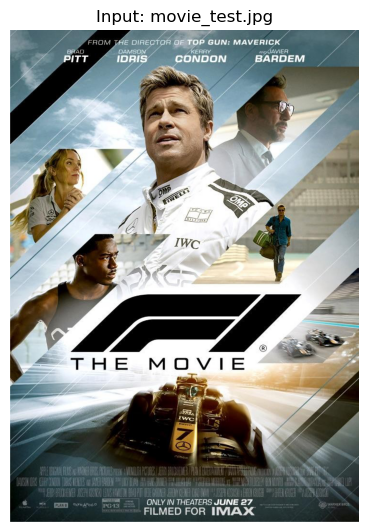


=== initial_best ===
Top-5 genres:


,genre,prob
0,Action,0.644755
1,Crime,0.627185
2,Comedy,0.585820
3,Drama,0.493347
4,Sci-Fi,0.395593


Predicted labels at threshold=0.45:
['Action', 'Crime', 'Comedy', 'Drama']
threshold=0.45 -> 4 labels
['Action', 'Crime', 'Comedy', 'Drama']
threshold=0.55 -> 3 labels
['Action', 'Crime', 'Comedy']

=== further_trained_best ===
Top-5 genres:


,genre,prob
0,Crime,0.868563
1,Action,0.753923
2,Thriller,0.642558
3,Drama,0.587905
4,Comedy,0.445240


Predicted labels at threshold=0.45:
['Crime', 'Action', 'Thriller', 'Drama']
threshold=0.45 -> 4 labels
['Crime', 'Action', 'Thriller', 'Drama']
threshold=0.55 -> 4 labels
['Crime', 'Action', 'Thriller', 'Drama']

Checkpoint comparison summary:


,model,num_labels@0.45,top1_genre,top1_prob,top3
0,initial_best,4,Action,0.6448,"Action, Crime, Comedy"
1,further_trained_best,4,Crime,0.8686,"Crime, Action, Thriller"


In [5]:
import matplotlib.pyplot as plt

# Show the input image once.
img = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(4.5, 6.5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Input: {IMAGE_PATH.name}")
plt.show()

# Compare predictions across all available checkpoints.
summary_rows = []
for model_label, model in MODELS.items():
    prob_df = predict_image_probs(model, IMAGE_PATH)

    print(f"\n=== {model_label} ===")
    print(f"Top-{TOP_K} genres:")
    display(prob_df.head(TOP_K))

    pred_labels = labels_above_threshold(prob_df, THRESHOLD)
    print(f"Predicted labels at threshold={THRESHOLD:.2f}:")
    print(pred_labels if pred_labels else "(none)")

    # Threshold sensitivity
    for thr in [0.45, 0.55]:
        labels = labels_above_threshold(prob_df, thr)
        print(f"threshold={thr:.2f} -> {len(labels)} labels")
        print(labels if labels else "(none)")

    summary_rows.append(
        {
            "model": model_label,
            f"num_labels@{THRESHOLD:.2f}": len(pred_labels),
            "top1_genre": prob_df.iloc[0]["genre"],
            "top1_prob": float(prob_df.iloc[0]["prob"]),
            "top3": ", ".join(prob_df.head(3)["genre"].tolist()),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df["top1_prob"] = summary_df["top1_prob"].round(4)
print("\nCheckpoint comparison summary:")
display(summary_df)